<a href="https://colab.research.google.com/github/kauya02053-sketch/Stock-Analysis/blob/main/Stock_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_428/1534537690.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock_id, start="2024-01-01")
[*********************100%***********************]  1 of 1 completed


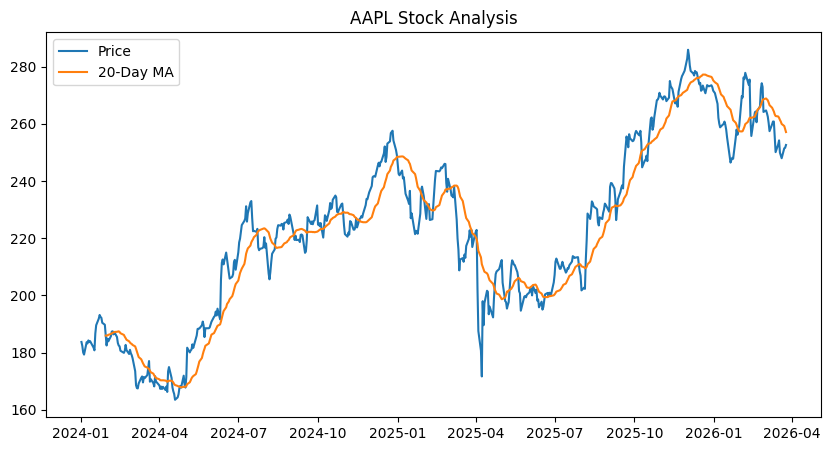

當前價格: 252.62, 20日均線: 257.15
建議: 看空 (價格在均線下)


/tmp/ipykernel_428/1534537690.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  current_price = current_price[0]


<Figure size 640x480 with 0 Axes>

In [4]:
# 1. 安裝與匯入工具
!pip install yfinance matplotlib -q
import yfinance as yf
import matplotlib.pyplot as plt

# 2. 設定你要分析的股票代號 (例如: AAPL 或 2330.TW)
stock_id = 'AAPL'
data = yf.download(stock_id, start="2024-01-01")

# 3. 簡單分析：計算 20 日均線
data['MA20'] = data['Close'].rolling(window=20).mean()

# 4. 畫圖：房價走勢與均線
plt.figure(figsize=(10, 5))
plt.plot(data['Close'], label='Price')
plt.plot(data['MA20'], label='20-Day MA')
plt.title(f'{stock_id} Stock Analysis')
plt.legend()
plt.show()

# 5. 輸出結論（防呆加強版）
# 使用 .iloc[-1] 取得最後一筆，並用 .item() 強制轉成純數字
current_price = data['Close'].iloc[-1]
ma_price = data['MA20'].iloc[-1]

# 如果抓出來還是 Series，我們取第一個值
if hasattr(current_price, '__len__'):
    current_price = current_price[0]
if hasattr(ma_price, '__len__'):
    ma_price = ma_price[0]

print(f"當前價格: {float(current_price):.2f}, 20日均線: {float(ma_price):.2f}")
print("建議: " + ("看多 (價格在均線上)" if current_price > ma_price else "看空 (價格在均線下)"))

# 儲存圖片
plt.savefig('result.png')

